In [114]:
from tree_search import *
from tree_analysis import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
data_folder = "../../monkey_4iar/analysis/data/processed/harry/models/2023-week-41"
fold_idx = 0
index = 0

train_data = pd.read_csv(f"{data_folder}/split_{fold_idx}.csv")
trial = train_data.iloc[index]

In [116]:
black_, white_, move_= trial.black, trial.white, trial.move
board = fourbynine_board(fourbynine_pattern(int(black_)), fourbynine_pattern(int(white_)))
actual_move = int(move_).bit_length() - 1

           Parameter :       lo      plo       x0      phi       hi
   pruning_threshold :    0.100    1.000    2.300    4.000   10.000
       stopping_prob :    0.010    0.010    0.300    0.900    1.000
        feature_drop :    0.000    0.010    0.250    0.400    1.000
          lapse_rate :    0.000    0.010    0.100    0.500    1.000
           opp_scale :    0.250    1.200    1.000    3.000    4.000
       center_weight :  -10.000   -3.000    0.100    3.000   10.000
                1IAR :   -5.000   -2.600   -0.600    1.400   15.000
            2IAR_CON :   -5.000   -0.900    1.100    3.100   15.000
            2IAR_DIS :   -5.000   -2.400   -0.400    1.600   15.000
            3IAR_CON :   -5.000    3.000    5.000    7.000   15.000
            3IAR_DIS :   -5.000    0.100    2.100    4.100   15.000
                4IAR :   -5.000   10.500   12.500   14.500   15.000


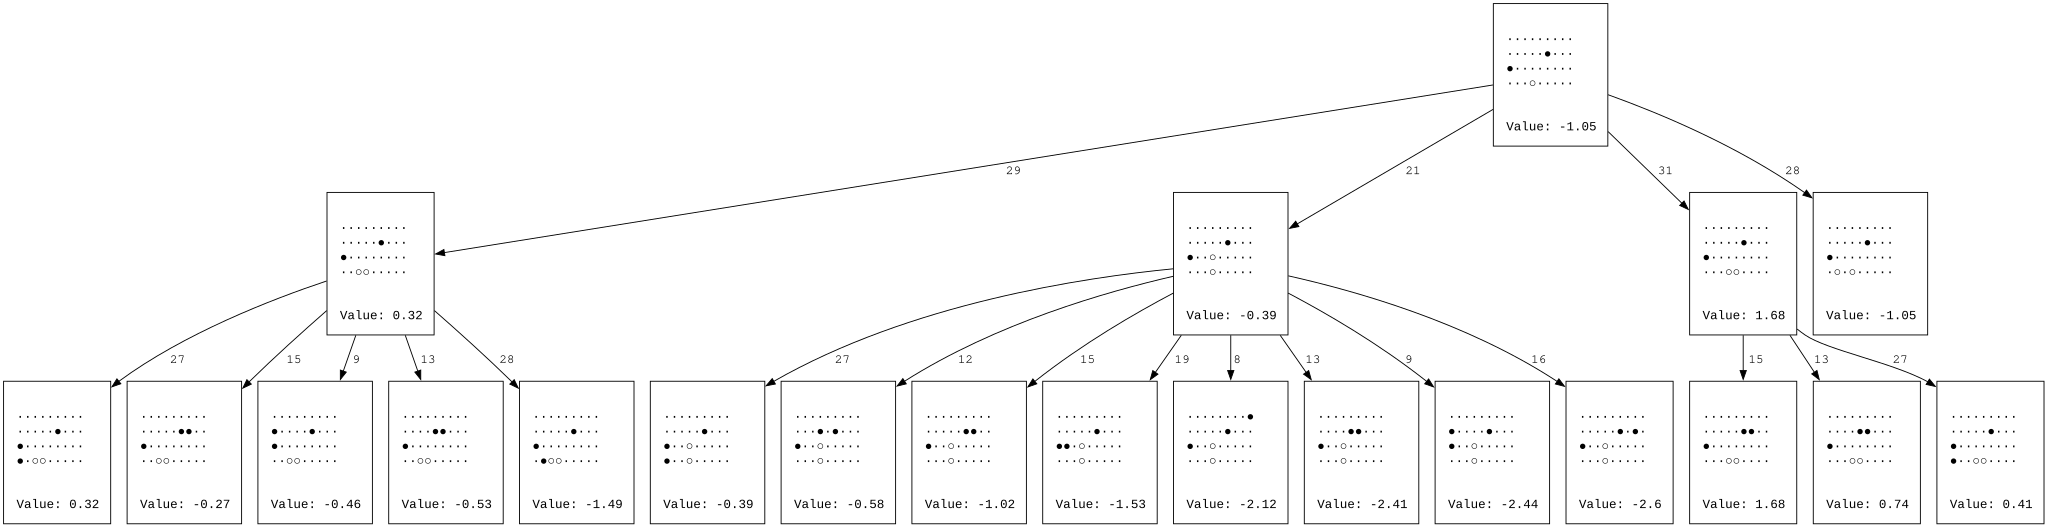

In [117]:
self = TreeSearch()
self.set_params(self.initial_params)
heuristic = self.heuristic
search = fourbynine.NInARowBestFirstSearch(heuristic, board)
search.complete_search()
root = search.get_tree()
tree_to_graphviz(root)

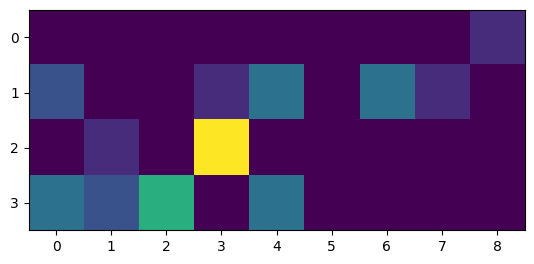

In [ ]:
hist = get_visits(root, use_paths = True)
plt.imshow(hist.reshape(4, 9))


In [161]:
hist = np.zeros(36)
for _ in range (500): 
    search = fourbynine.NInARowBestFirstSearch(heuristic, board)
    search.complete_search()
    root = search.get_tree()
    hist += get_visits(root, use_paths = True)

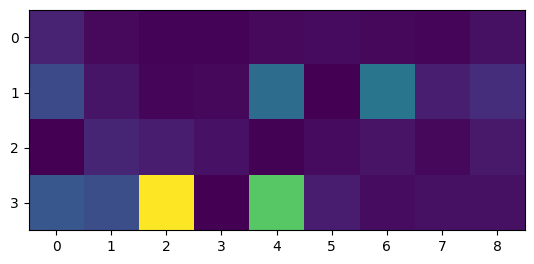

In [162]:
plt.imshow(hist.reshape(4, 9))
